# Import all requirements

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Dataset

In [37]:
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 60)

CSV = "logistics_predictive_maintenanceV2.csv"
data = pd.read_csv(CSV)
print("shape:", data.shape)

shape: (250000, 50)


In [38]:
data.sample(5)

,Vehicle_ID,Make_and_Model,Vehicle_Type,Year_of_Manufacture,Route_Info,Weather_Conditions,Road_Conditions,Communication_Interface,Telematics_Gateway,Edge_Device_Class,Usage_Hours,Load_Capacity,Actual_Load,Engine_Temperature,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Oil_Quality,Failure_History,Anomalies_Detected,Diagnostic_Trouble_Code_Count,CAN_Message_Rate_Hz,Sensor_Packet_Loss_Rate,Maintenance_Cost,Historical_Maintenance_Cost,Downtime_Maintenance,Impact_on_Efficiency,Days_Since_Last_Maintenance,Last_Maintenance_Date,Maintenance_Type,Brake_Condition,Maintenance_Severity,Maintenance_Severity_ID,Maintenance_Required,PCR,UIR,TPI,MBF,ADS,OHI,CMES,UER,Predictive_Score,Pre_Event_Record,Data_Split,FL_Client_ID,Partition_Type,Local_Epochs_Per_Round,Communication_Rounds
181571,181572,Volvo FH,Medium Truck,2017,Cold-Chain Route,Humid,Rough,CAN/LIN,OBD_Gateway,ARM_Cortex_A53,12008.9562,2500,1445.5189,72.6002,34.2324,8.0519,90.6210,1.6724,86.1434,0,0,0,52.1469,0.0026,148.5557,148.5557,2.3848,0.1177,154,2024-07-31,Tire Rotation,Fair,Normal,0,0,0.5782,0.6672,2.1208,148.5557,0.0,1.5067,3.3329,80.2976,0.1780,1,Train,1,Non-IID Dirichlet alpha=0.5,2,200
90027,90028,Mercedes Actros,Light Truck,2016,Highway Freight,Clear,Rough,CAN-FD/Telematics,Edge_Telematics_Box,ARM_Cortex_A53,12857.4694,5000,3045.9799,101.4680,31.1436,10.8966,60.6532,3.7811,70.5438,2,3,1,60.2022,0.0313,1045.6494,1045.6494,2.1920,0.2905,225,2024-05-21,Battery Service,Poor,Minor Maintenance,1,1,0.6092,0.6429,3.2581,1568.4741,4.2,1.9584,5.3580,12.2844,0.4471,1,Train,2,Non-IID Dirichlet alpha=0.5,2,200
81727,81728,Isuzu NPR,Medium Truck,2011,Highway Freight,Hot,Mountainous,CAN-FD/Telematics,OBD_Gateway,ARM_Cortex_A53,19503.3704,10000,3790.8342,97.2936,34.9696,6.5250,71.2430,0.9593,87.3604,0,0,1,55.0049,0.0073,127.8384,127.8384,1.8862,0.1688,75,2024-10-18,Routine Inspection,Good,Normal,0,0,0.3791,0.6501,2.7822,127.8384,0.2,2.1727,2.9876,151.3785,0.2921,1,Train,1,Non-IID Dirichlet alpha=0.5,2,200
120142,120143,Volvo FH,Refrigerated Truck,2021,Intercity Logistics,Clear,Mountainous,CAN/LIN,Embedded_TCU,ARM_Cortex_A53,5632.2061,25000,13804.3266,93.7719,30.6802,7.5507,78.3142,0.7393,80.9699,0,0,0,29.5740,0.0074,300.6782,300.6782,0.5461,0.1661,77,2024-10-16,Routine Inspection,Good,Normal,0,0,0.5522,0.5632,3.0564,300.6782,0.0,0.8274,1.8004,18.6696,0.2536,1,Test,1,Non-IID Dirichlet alpha=0.5,2,200
7478,7479,Volvo FH,Electric Truck,2013,Highway Freight,Humid,Congested,OBD-II/CAN,Embedded_TCU,ARM_Cortex_A72,16963.9112,1500,544.6149,87.9059,37.5711,9.2992,85.3209,0.3686,86.3622,0,0,0,35.1725,0.0117,302.9331,302.9331,0.9069,0.0437,70,2024-10-23,Tire Rotation,Good,Normal,0,0,0.3631,0.6525,2.3397,302.9331,0.0,1.8696,1.3135,55.8146,0.1733,1,Validation,1,Non-IID Dirichlet alpha=0.5,2,200


# Understand the Data

In [39]:
data.shape

(250000, 50)

In [40]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 50 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Vehicle_ID                     250000 non-null  int64  
 1   Make_and_Model                 250000 non-null  object 
 2   Vehicle_Type                   250000 non-null  object 
 3   Year_of_Manufacture            250000 non-null  int64  
 4   Route_Info                     250000 non-null  object 
 5   Weather_Conditions             250000 non-null  object 
 6   Road_Conditions                250000 non-null  object 
 7   Communication_Interface        250000 non-null  object 
 8   Telematics_Gateway             250000 non-null  object 
 9   Edge_Device_Class              250000 non-null  object 
 10  Usage_Hours                    250000 non-null  float64
 11  Load_Capacity                  250000 non-null  int64  
 12  Actual_Load                   

Fix Date data-type

In [41]:
data['Last_Maintenance_Date'] = pd.to_datetime(data['Last_Maintenance_Date'])

In [42]:
data.isnull().sum()

Vehicle_ID                       0
Make_and_Model                   0
Vehicle_Type                     0
Year_of_Manufacture              0
Route_Info                       0
Weather_Conditions               0
Road_Conditions                  0
Communication_Interface          0
Telematics_Gateway               0
Edge_Device_Class                0
Usage_Hours                      0
Load_Capacity                    0
Actual_Load                      0
Engine_Temperature               0
Tire_Pressure                    0
Fuel_Consumption                 0
Battery_Status                   0
Vibration_Levels                 0
Oil_Quality                      0
Failure_History                  0
Anomalies_Detected               0
Diagnostic_Trouble_Code_Count    0
CAN_Message_Rate_Hz              0
Sensor_Packet_Loss_Rate          0
Maintenance_Cost                 0
Historical_Maintenance_Cost      0
Downtime_Maintenance             0
Impact_on_Efficiency             0
Days_Since_Last_Main

In [43]:
data.duplicated().sum()

np.int64(0)

# Categorize the columns

### Removing unwanted columns

In [44]:
data[['Maintenance_Required', 'Load_Capacity', 'Actual_Load', 'PCR']].corr()

,Maintenance_Required,Load_Capacity,Actual_Load,PCR
Maintenance_Required,1.000000,0.000088,0.222758,0.668414
Load_Capacity,0.000088,1.000000,0.911354,0.001868
Actual_Load,0.222758,0.911354,1.000000,0.334937
PCR,0.668414,0.001868,0.334937,1.000000


No of unique values in 'Pre_Event_Record' Column:  1


,Maintenance_Required,Predictive_Score,Maintenance_Severity_ID
Maintenance_Required,1.000000,0.864786,0.921132
Predictive_Score,0.864786,1.000000,0.963906
Maintenance_Severity_ID,0.921132,0.963906,1.000000


<Axes: xlabel='Predictive_Score', ylabel='Count'>

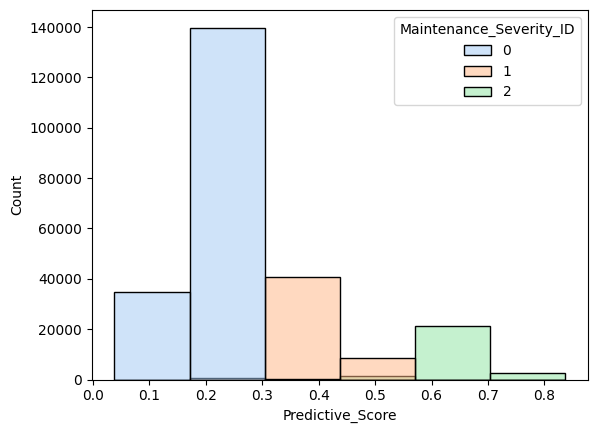

In [45]:
print("No of unique values in 'Pre_Event_Record' Column: ", data['Pre_Event_Record'].nunique())
display(data[['Maintenance_Required','Predictive_Score', 'Maintenance_Severity_ID']].corr())

sns.histplot( x = data['Predictive_Score'], hue=data['Maintenance_Severity_ID'], bins=6, palette="pastel")

In [46]:
# Feature used to extract new featues > No need
OPTIMISED = ['Load_Capacity', 'Actual_Load']

#Does not take any part in final prediction 
USELESS = ['Communication_Interface','Telematics_Gateway','Edge_Device_Class', # Useless data about IoT Device
           'Pre_Event_Record', 'Predictive_Score']

# Features for training/ Testing, model training
FL = ['FL_Client_ID', 'Partition_Type', 'Local_Epochs_Per_Round', 'Communication_Rounds']

to_drop =  OPTIMISED + USELESS  + FL # Pre_Event_Record contain one one value
data.drop(to_drop, axis = 1, inplace = True)

### Categorise Features

In [47]:
data.nunique()

Vehicle_ID                       250000
Make_and_Model                        8
Vehicle_Type                          5
Year_of_Manufacture                  15
Route_Info                            5
Weather_Conditions                    6
Road_Conditions                       5
Usage_Hours                      249199
Engine_Temperature               178710
Tire_Pressure                    111961
Fuel_Consumption                  95782
Battery_Status                   188946
Vibration_Levels                  58297
Oil_Quality                      182536
Failure_History                      11
Anomalies_Detected                   14
Diagnostic_Trouble_Code_Count        17
CAN_Message_Rate_Hz              192551
Sensor_Packet_Loss_Rate             988
Maintenance_Cost                 241458
Historical_Maintenance_Cost      241458
Downtime_Maintenance              80100
Impact_on_Efficiency               6949
Days_Since_Last_Maintenance         701
Last_Maintenance_Date               701


In [48]:
IDS = ['Vehicle_ID','Make_and_Model','Vehicle_Type','Year_of_Manufacture','Route_Info']

# Impactfull features
FEATURES = ['Weather_Conditions','Road_Conditions','Usage_Hours',
            'Engine_Temperature','Tire_Pressure','Fuel_Consumption','Battery_Status','Vibration_Levels','Oil_Quality',
            'Brake_Condition', ]

PAST = ['Failure_History', 'Maintenance_Cost', 'Historical_Maintenance_Cost', 'Downtime_Maintenance',
        'Impact_on_Efficiency', 'Days_Since_Last_Maintenance', 'Last_Maintenance_Date', 'Maintenance_Type']

UNKNOWN = ['Anomalies_Detected', 'Diagnostic_Trouble_Code_Count', 'CAN_Message_Rate_Hz', 'Sensor_Packet_Loss_Rate', ]

# Extracted Features
E_FEATURE = ['PCR','UIR','TPI','MBF','ADS','OHI','CMES','UER']                          # Valid : PCR

# Predefined train-test-split column
TRAIN_TEST_SPLIT= ['Data_Split']
# Outputs
LABELS = ['Maintenance_Required', 'Maintenance_Severity', 'Maintenance_Severity_ID']

In [49]:
CAT = ['Make_and_Model', 'Vehicle_Type', 'Year_of_Manufacture', 'Route_Info',              # IDS
       'Weather_Conditions', 'Road_Conditions',                                 
       'Failure_History', 'Anomalies_Detected', 'Diagnostic_Trouble_Code_Count',           # for both CAT/NUM
       'Maintenance_Type',
       'Brake_Condition',]

NUM = ['Usage_Hours', 
       'Engine_Temperature', 'Tire_Pressure', 'Fuel_Consumption', 'Battery_Status', 'Vibration_Levels', 'Oil_Quality',
        'Failure_History','Anomalies_Detected', 'Diagnostic_Trouble_Code_Count',           # for both CAT/NUM
        'CAN_Message_Rate_Hz', 'Sensor_Packet_Loss_Rate', 
        'Maintenance_Cost', 'Historical_Maintenance_Cost', 'Downtime_Maintenance', 'Impact_on_Efficiency', 
        'Days_Since_Last_Maintenance', 'Last_Maintenance_Date','Maintenance_Type']

In [50]:
used = list(set(IDS + FEATURES + PAST + CAT + NUM + LABELS + E_FEATURE + UNKNOWN + TRAIN_TEST_SPLIT))

F = list(data.drop(used, axis = 1).columns)
print("n_features:", len(F))

n_features: 0


In [51]:
TO_USE = list(set(CAT + NUM + E_FEATURE 
                + LABELS 
                + TRAIN_TEST_SPLIT))

F = list(data.drop(TO_USE, axis = 1).columns)
print("n_features:", len(F))
F

n_features: 1


['Vehicle_ID']

In [52]:
len(list(data.columns))

39

In [53]:
len(TO_USE)

38

# Till Wednesday

In [54]:
df = data.drop(['Vehicle_ID', 'Maintenance_Required', 'Maintenance_Severity'], axis = 1)

# Train test split

In [55]:
df = data.drop(['Vehicle_ID', 'Maintenance_Required', 'Maintenance_Severity'], axis = 1)
df['Data_Split'].value_counts()

Data_Split
Train         175000
Test           50000
Validation     25000
Name: count, dtype: int64

In [56]:
train = df[df['Data_Split'] == 'Train']
test = df[df['Data_Split'] == 'Test']
Validation_set = df[df['Data_Split'] == 'Validation']

Validation_set = Validation_set[df.columns]
X_train, y_train = train[df.columns], train['Maintenance_Severity_ID']
X_test, y_test = test[df.columns], test['Maintenance_Severity_ID']

In [57]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape, Validation_set.shape

((175000, 36), (175000,), (50000, 36), (50000,), (25000, 36))

# EDA

## Categorical Column Analysis

In [58]:
len(CAT)

11

### Count plut

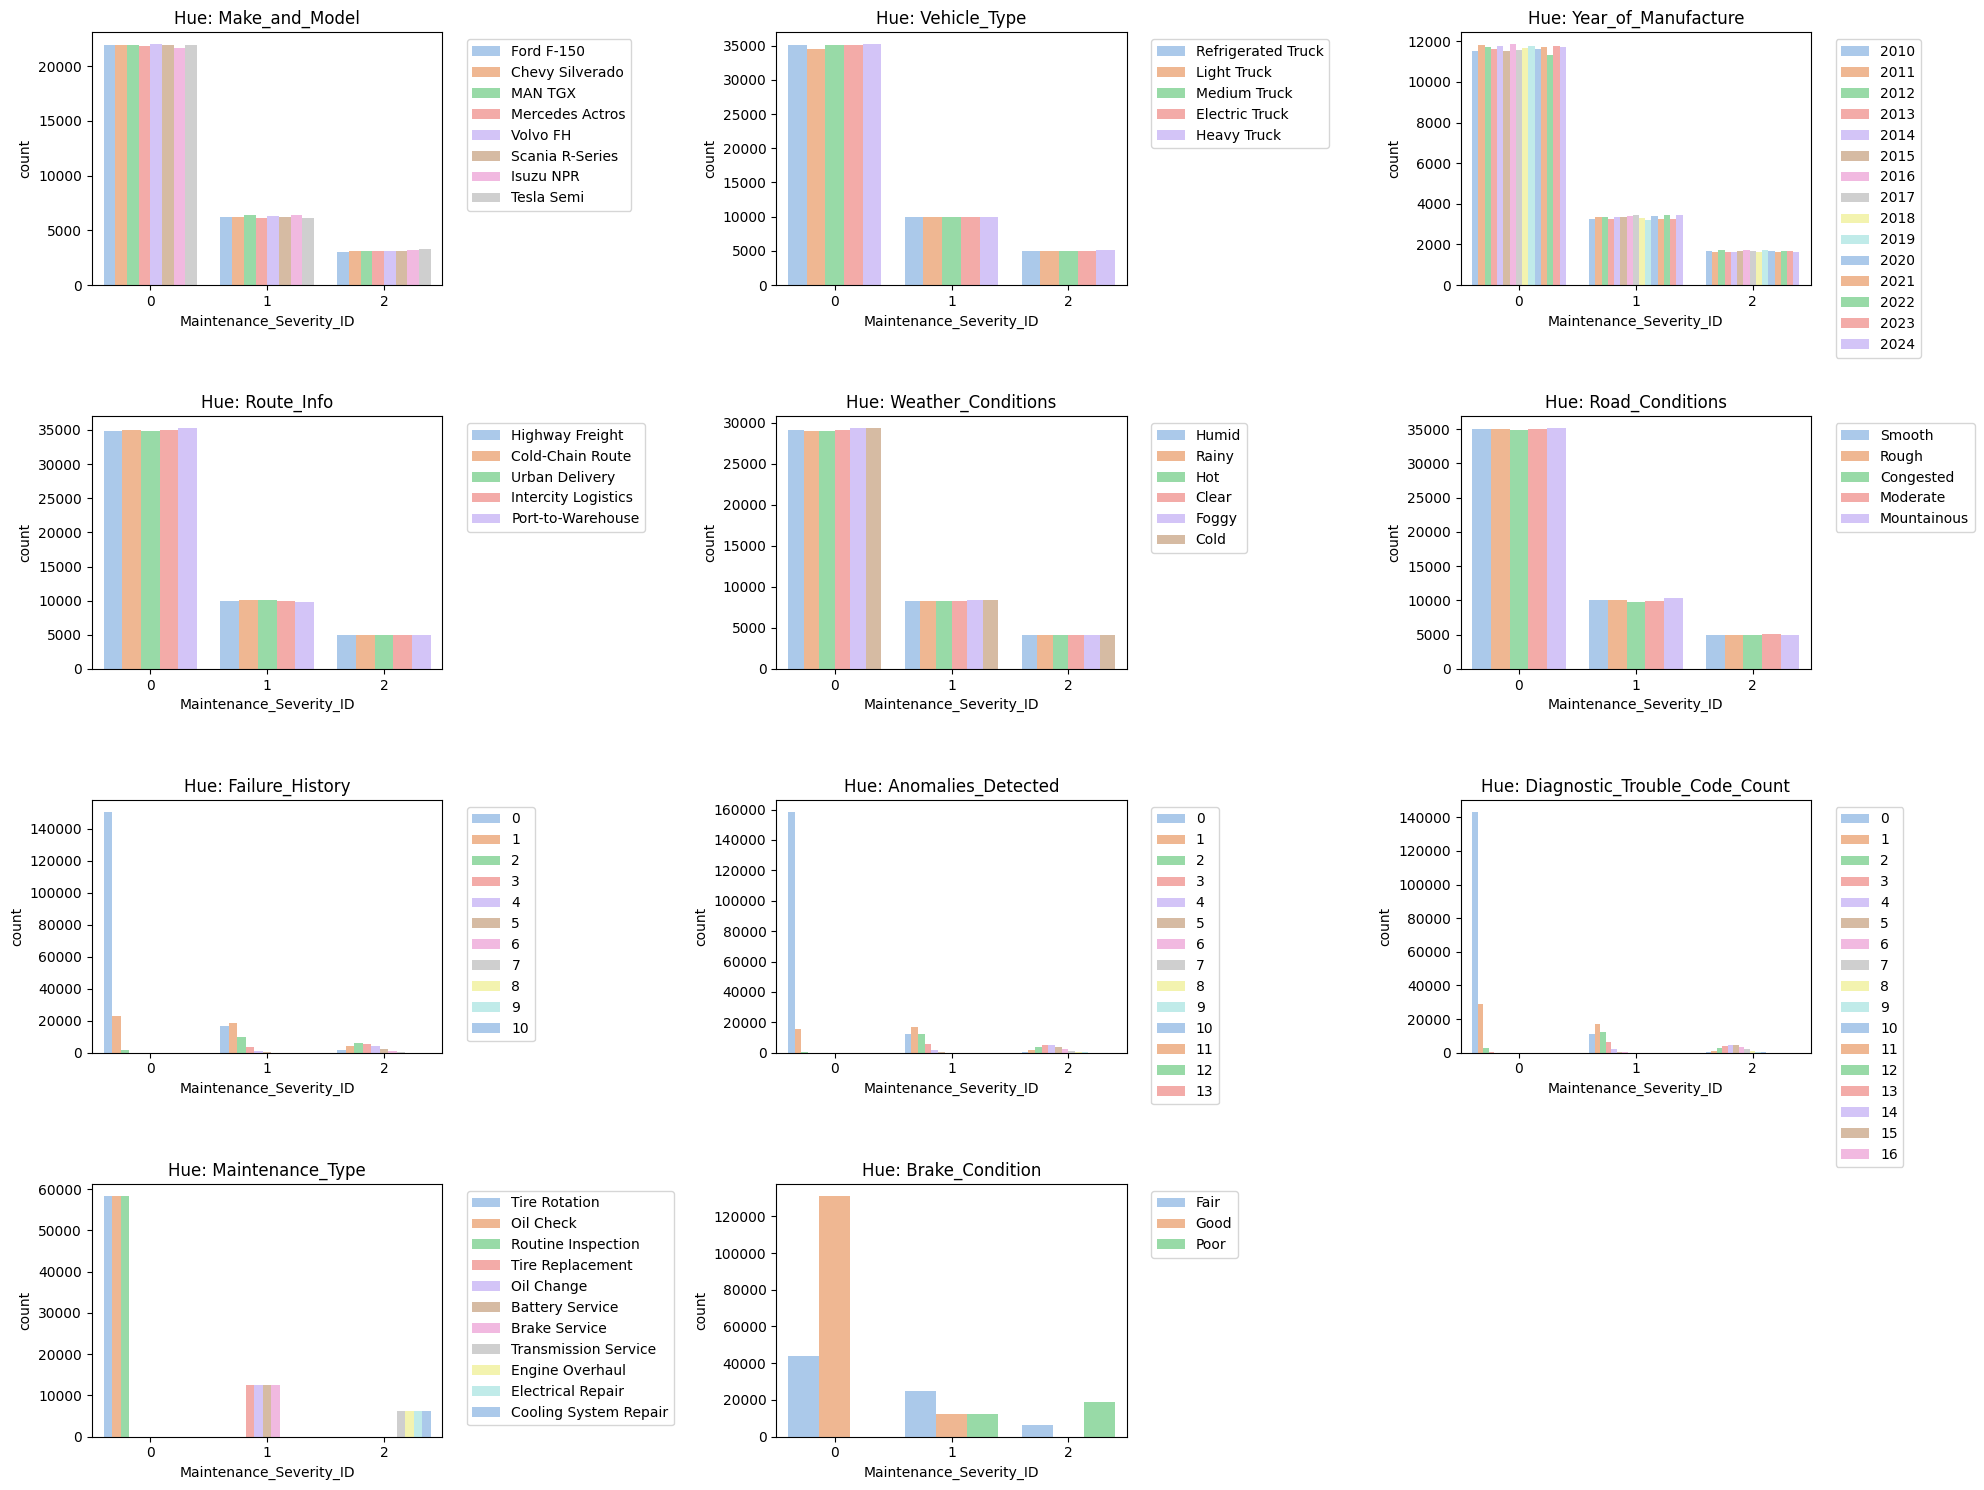

In [59]:
plt.figure(figsize=(20, 15))

for i in range (0, len(CAT)):
  plt.subplot(4, 3, i+1)
  plt.title("Hue: " + CAT[i])
  sns.countplot(data=df, x='Maintenance_Severity_ID', hue = CAT[i],palette="pastel")
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  plt.xlabel('Maintenance_Severity_ID')

plt.tight_layout()
plt.show()

## Numerical Column Analysis

In [60]:
len(NUM)

19

### Histogram

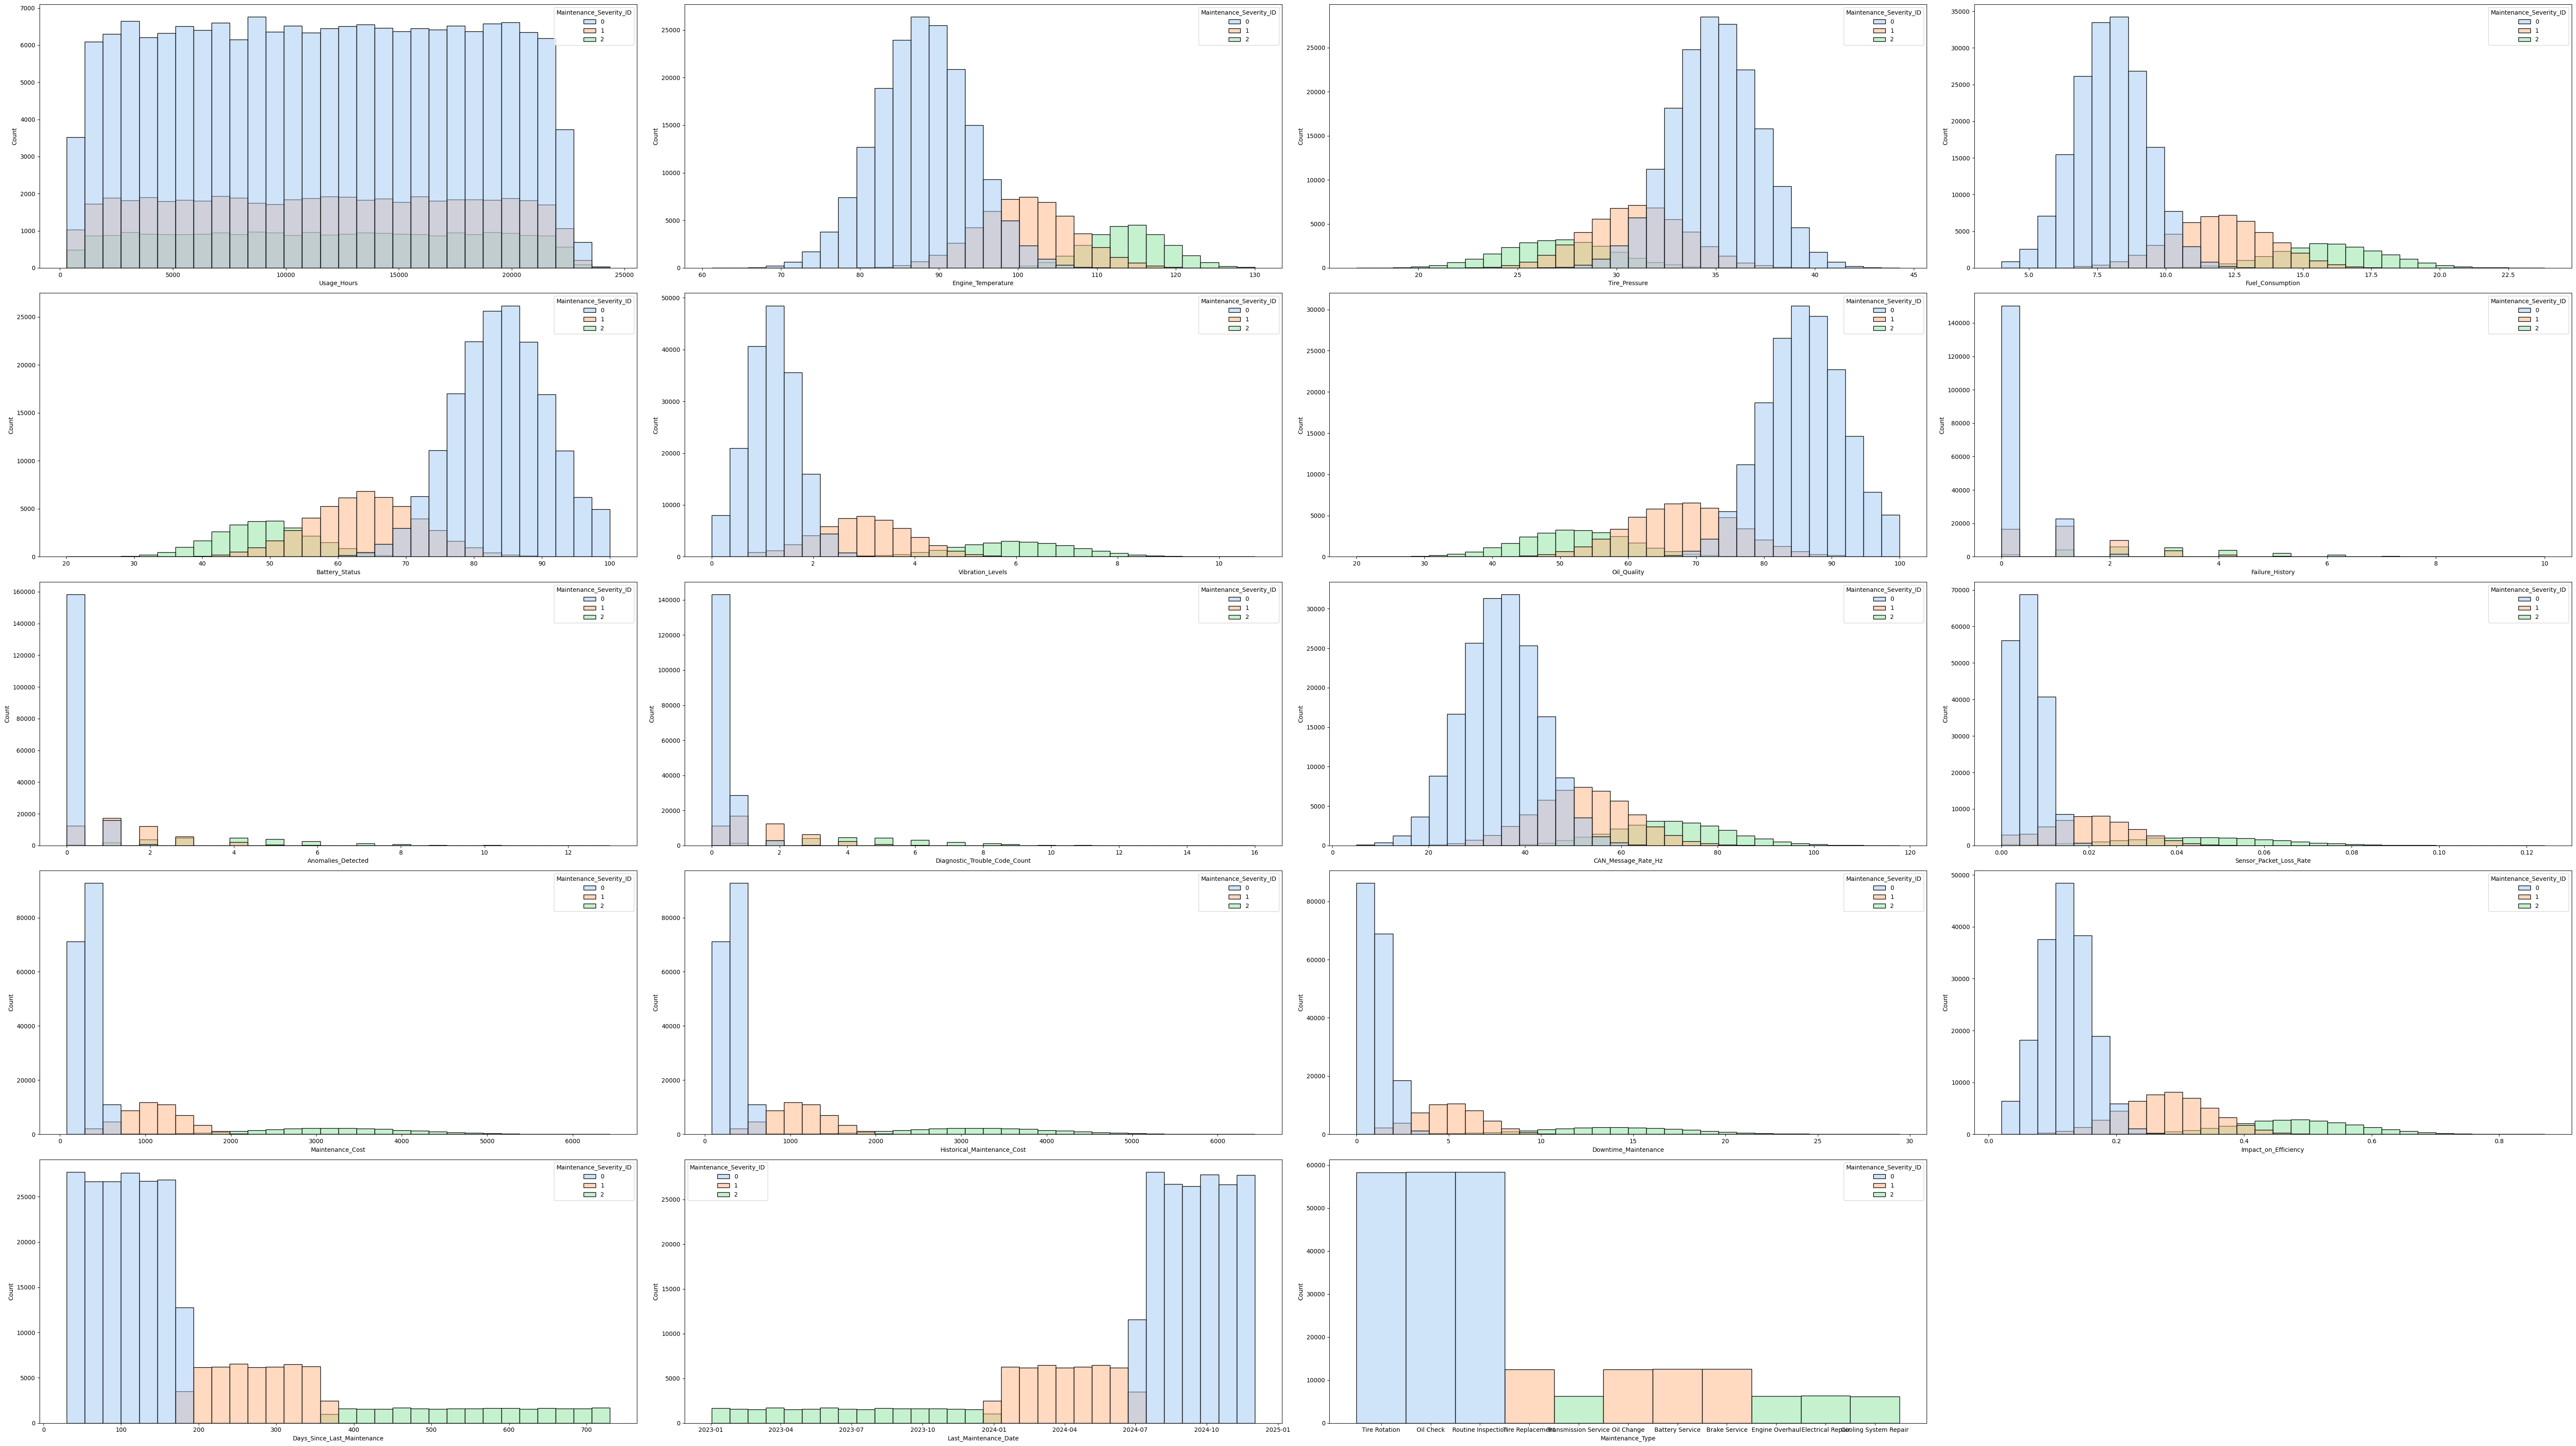

In [66]:
plt.figure(figsize=(60, 40))

for i in range(0, len(NUM)):
    plt.subplot(6, 4, i+1)
    sns.histplot(data=df, x=NUM[i], hue='Maintenance_Severity_ID', bins=30, palette="pastel")
    plt.xlabel(NUM[i])

plt.tight_layout()
plt.show()

### Boxplot for outlier

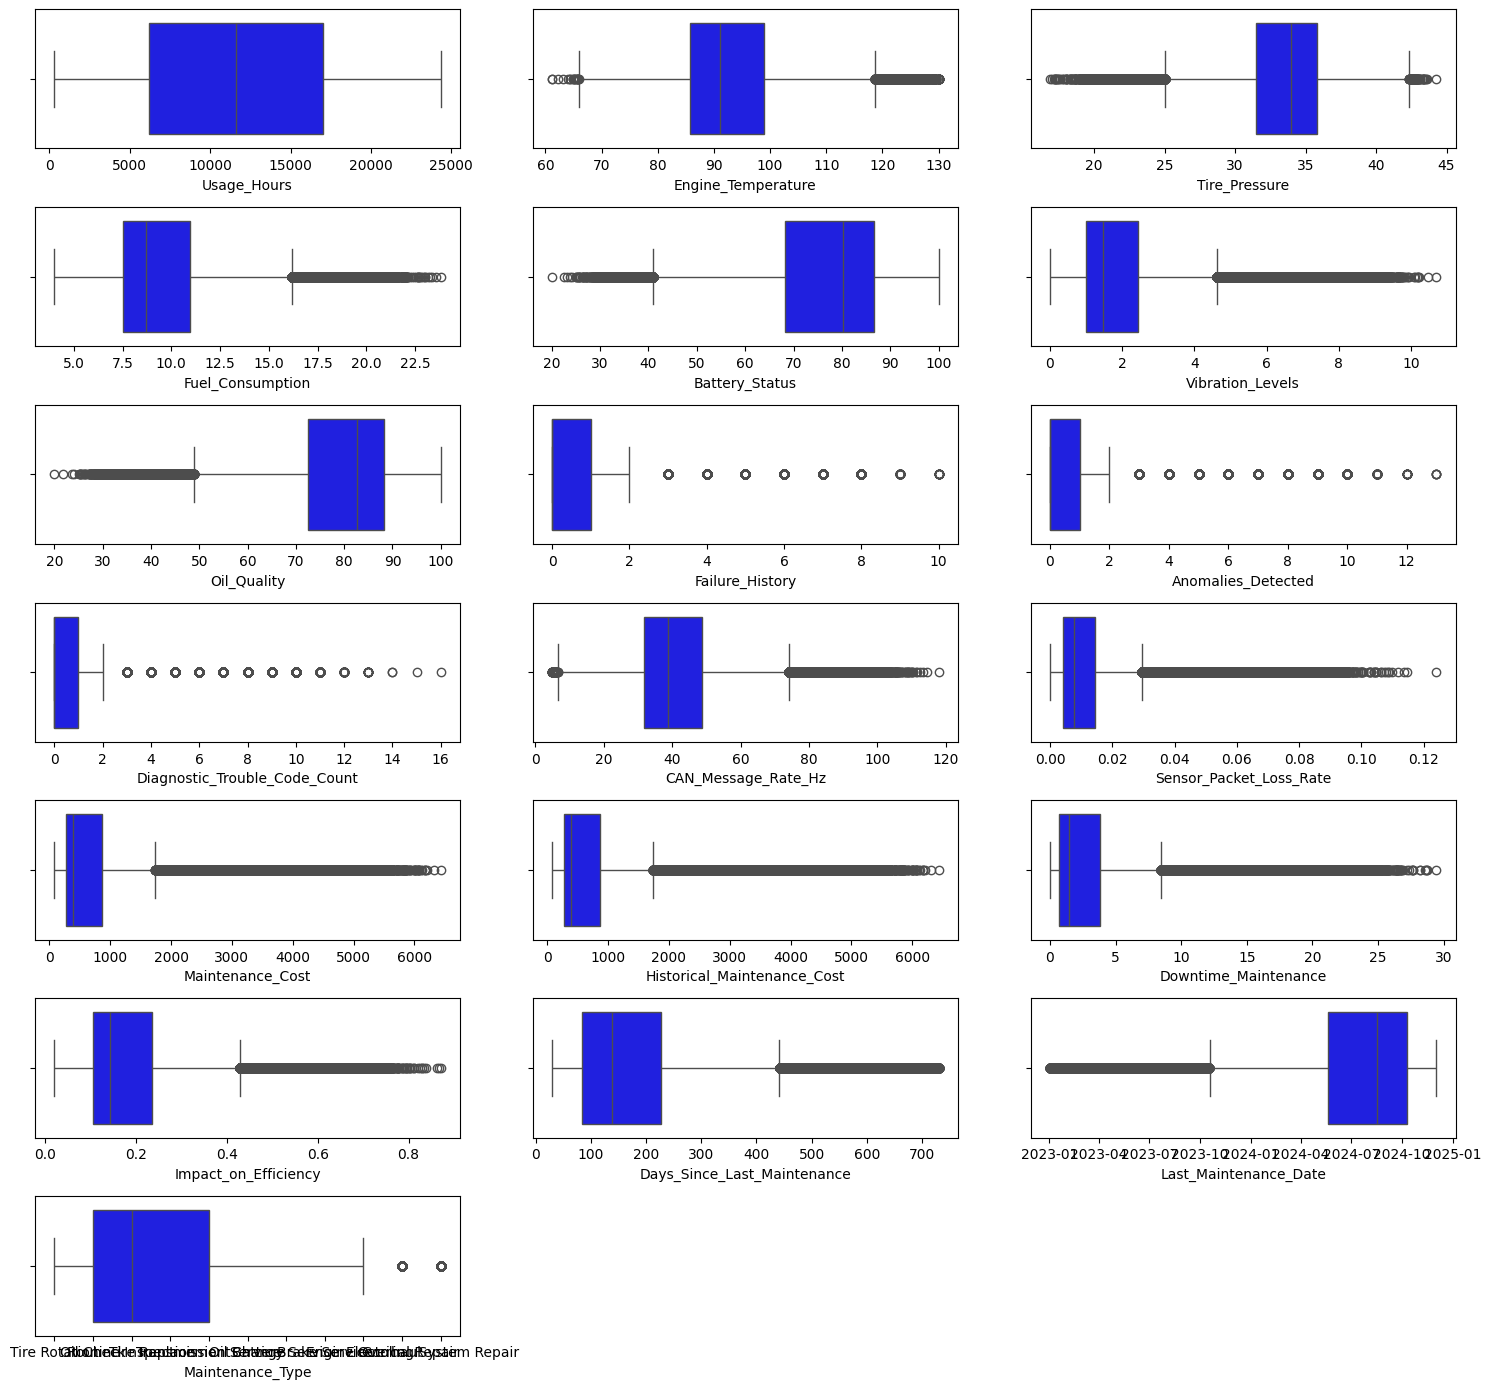

In [ ]:
plt.figure(figsize=(15, 14))

for i in range(0, len(NUM)):
    plt.subplot(7,3, i+1)
    sns.boxplot(x=df[NUM[i]], color='blue')
    plt.xlabel(NUM[i])
    plt.tight_layout()

### Violin Plot

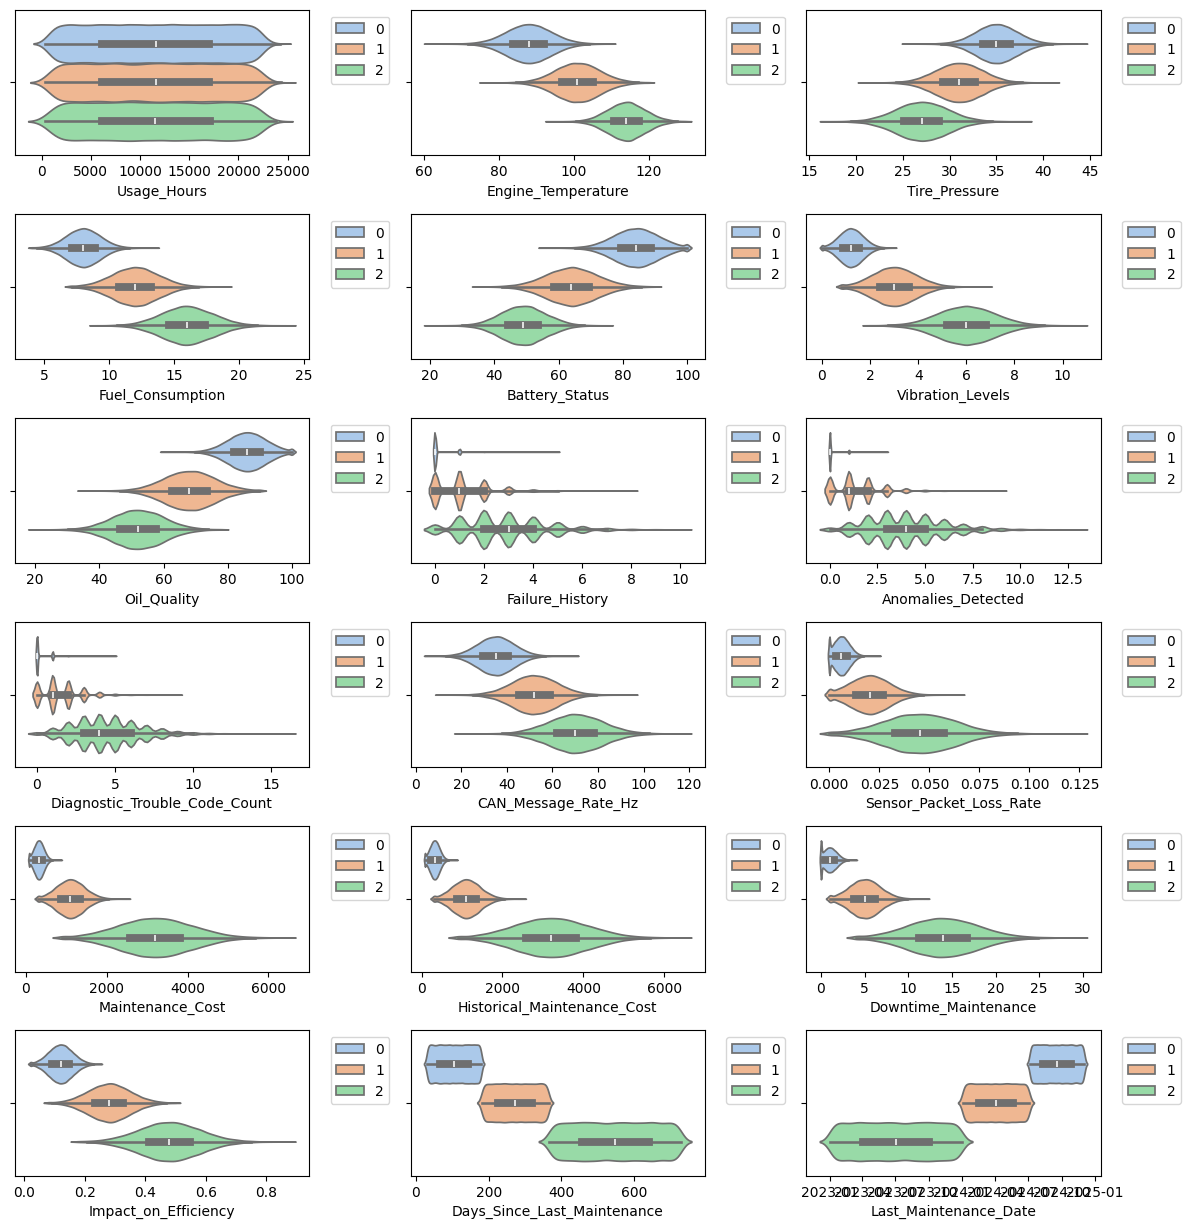

In [89]:
plt.figure(figsize=(12, 14)) #(X, y)

for i in range(len(NUM)-1):
    plt.subplot(7, 3, i+1) #(y_split, x_split, location)
    sns.violinplot(data=df, x=NUM[i], hue='Maintenance_Severity_ID', palette="pastel")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') 
    plt.xlabel(NUM[i])

plt.tight_layout()
plt.show()

### KDE Plot

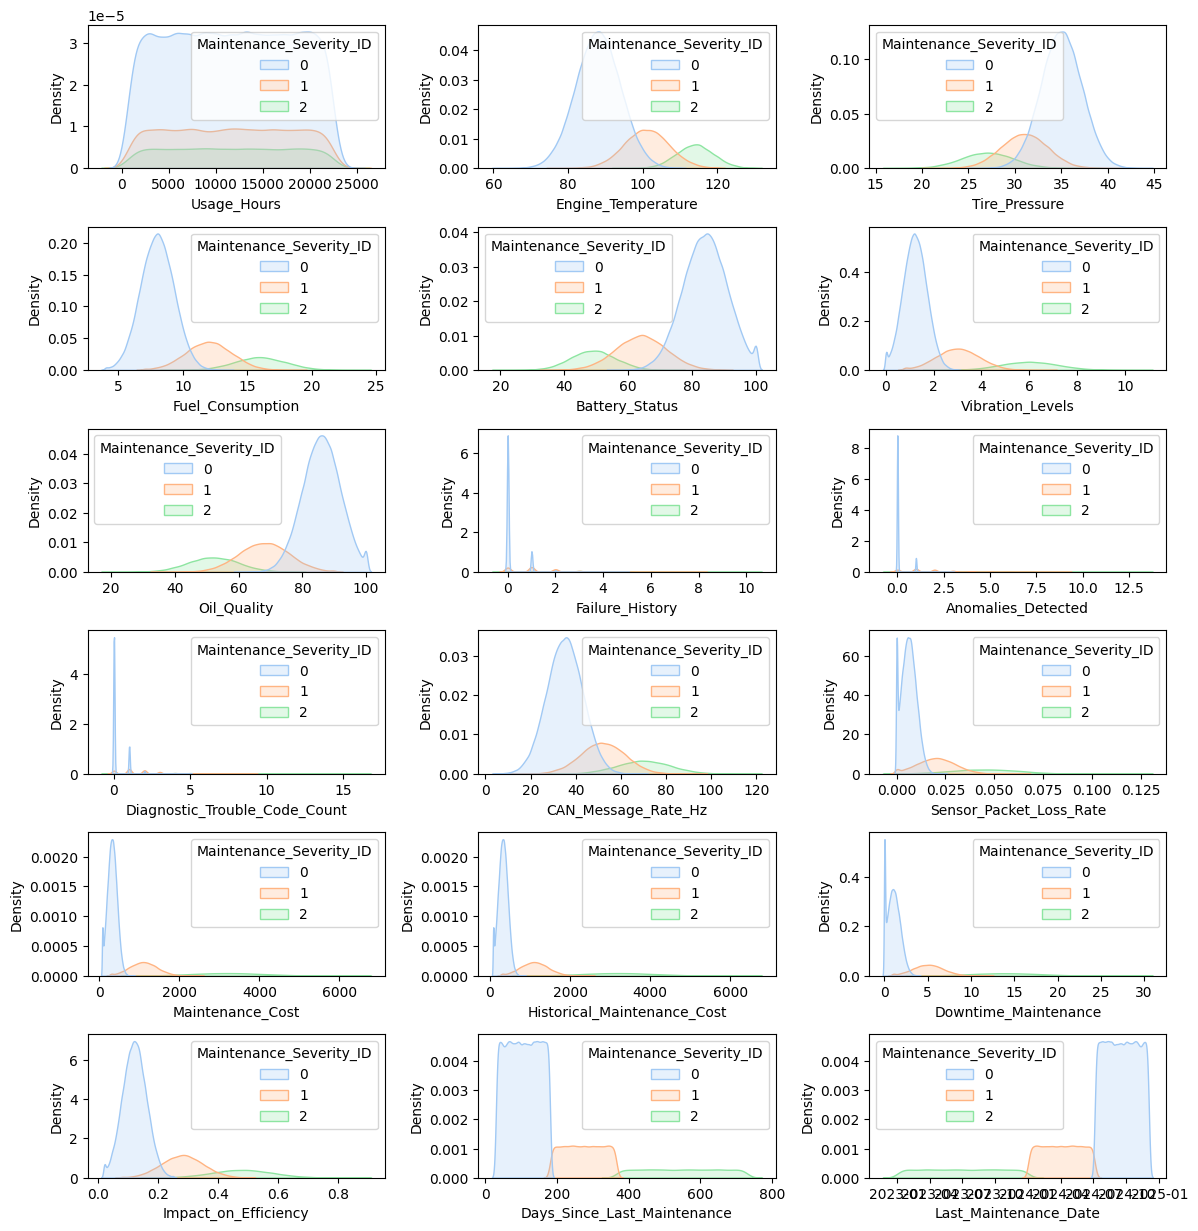

In [88]:
plt.figure(figsize=(12, 14)) #(X, y)

for i in range(len(NUM)-1):
    plt.subplot(7, 3, i+1) #(y_split, x_split, location)
    sns.kdeplot(data=df, x=NUM[i], hue='Maintenance_Severity_ID',fill=True, palette="pastel")
    plt.xlabel(NUM[i])

plt.tight_layout()
plt.show()

### Heatmap

In [62]:
df.corr(numeric_only= True)

,Year_of_Manufacture,Usage_Hours,Engine_Temperature,Tire_Pressure,Fuel_Consumption,Battery_Status,Vibration_Levels,Oil_Quality,Failure_History,Anomalies_Detected,Diagnostic_Trouble_Code_Count,CAN_Message_Rate_Hz,Sensor_Packet_Loss_Rate,Maintenance_Cost,Historical_Maintenance_Cost,Downtime_Maintenance,Impact_on_Efficiency,Days_Since_Last_Maintenance,Maintenance_Severity_ID,PCR,UIR,TPI,MBF,ADS,OHI,CMES,UER
Year_of_Manufacture,1.000000,-0.994666,0.000690,-0.000800,0.002248,-0.002273,0.002703,-0.002305,-0.000305,-0.000924,0.001855,0.003296,-0.001487,-0.000170,-0.000170,0.000237,0.000400,0.001157,0.001473,0.002868,-0.677994,0.000479,-0.000197,-0.000447,-0.908394,0.000490,-0.520690
Usage_Hours,-0.994666,1.000000,-0.000516,0.000680,-0.002061,0.002017,-0.002426,0.002172,0.000445,0.001115,-0.001611,-0.002889,0.001816,0.000470,0.000470,-0.000035,-0.000231,-0.000862,-0.001199,-0.002767,0.724005,-0.000253,0.000525,0.000655,0.913363,-0.000288,0.523691
Engine_Temperature,0.000690,-0.000516,1.000000,-0.619638,0.719071,-0.705945,0.741496,-0.712712,0.589469,0.655953,0.650407,0.653242,0.681843,0.739514,0.739514,0.743812,0.741576,0.759179,0.824400,0.610248,0.000940,0.888384,0.701692,0.718187,0.314211,0.773602,-0.363757
Tire_Pressure,-0.000800,0.000680,-0.619638,1.000000,-0.655353,0.644077,-0.675607,0.649011,-0.538239,-0.598367,-0.592651,-0.593817,-0.622620,-0.673790,-0.673790,-0.677346,-0.675313,-0.690961,-0.750829,-0.555560,-0.001413,-0.891318,-0.639616,-0.655177,-0.286027,-0.704531,0.332325
Fuel_Consumption,0.002248,-0.002061,0.719071,-0.655353,1.000000,-0.747391,0.783430,-0.753808,0.625612,0.693172,0.687516,0.689926,0.721757,0.782146,0.782146,0.785691,0.784324,0.802572,0.871529,0.643494,0.000194,0.770504,0.743065,0.759694,0.330745,0.844257,-0.384302
Battery_Status,-0.002273,0.002017,-0.705945,0.644077,-0.747391,1.000000,-0.764684,0.743311,-0.606899,-0.673783,-0.664473,-0.678254,-0.701449,-0.753303,-0.753303,-0.761018,-0.769231,-0.782424,-0.857979,-0.632169,0.000127,-0.752530,-0.710437,-0.737534,-0.324274,-0.792962,0.387307
Vibration_Levels,0.002703,-0.002426,0.741496,-0.675607,0.783430,-0.764684,1.000000,-0.775042,0.661063,0.735902,0.733671,0.712655,0.762218,0.838724,0.838724,0.838405,0.816897,0.844854,0.899213,0.667013,0.000730,0.802895,0.806827,0.806264,0.386445,0.869325,-0.381622
Oil_Quality,-0.002305,0.002172,-0.712712,0.649011,-0.753808,0.743311,-0.775042,1.000000,-0.616423,-0.684193,-0.676908,-0.683287,-0.711091,-0.768889,-0.768889,-0.774498,-0.776941,-0.793118,-0.864780,-0.637266,0.000837,-0.761518,-0.727795,-0.749300,-0.375883,-0.806170,0.385160
Failure_History,-0.000305,0.000445,0.589469,-0.538239,0.625612,-0.606899,0.661063,-0.616423,1.000000,0.589424,0.588733,0.567243,0.608893,0.671086,0.671086,0.672240,0.650972,0.673489,0.716740,0.533717,0.000841,0.640156,0.800539,0.772518,0.277312,0.696435,-0.301126
Anomalies_Detected,-0.000924,0.001115,0.655953,-0.598367,0.693172,-0.673783,0.735902,-0.684193,0.589424,1.000000,0.658440,0.631744,0.679724,0.753506,0.753506,0.748617,0.723825,0.751604,0.795507,0.591472,0.002438,0.713763,0.727914,0.960732,0.308886,0.775635,-0.331606


<Axes: >

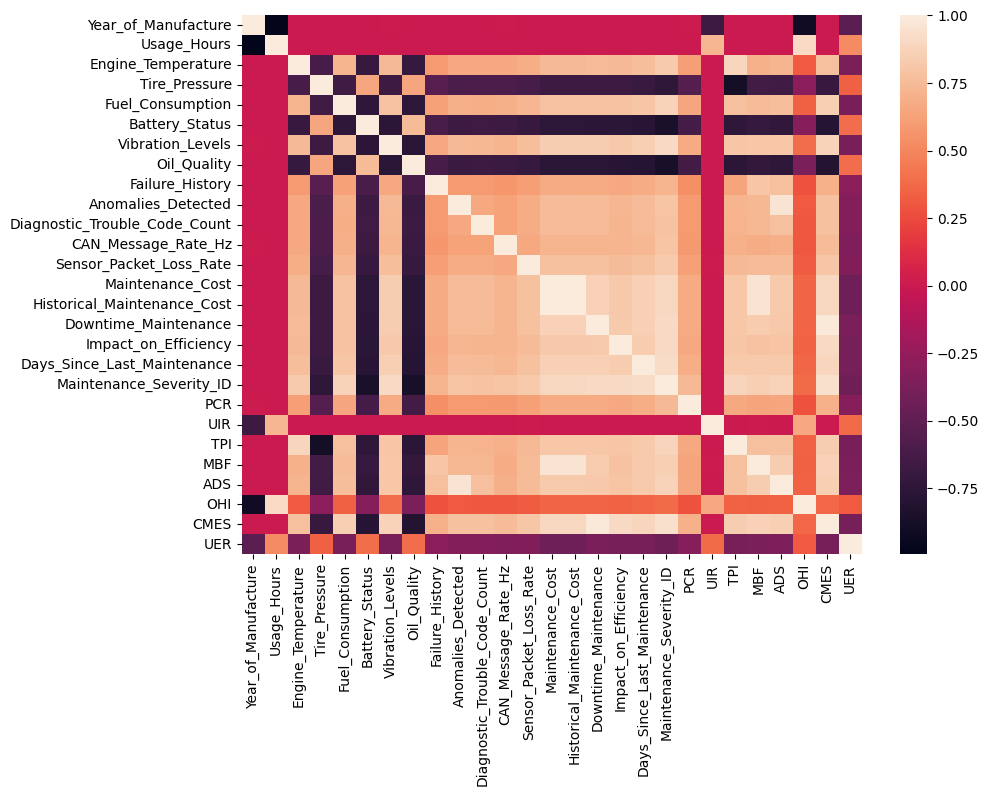

In [63]:
plt.figure(figsize=(10, 7))
sns.heatmap(df.corr(numeric_only= True))

# ydata-profiling

In [65]:
# from ydata_profiling import ProfileReport

# profile = ProfileReport(
#     df,
#     title="Predictive Maintenance Dataset Report"    
# )

# profile.to_file("maintenance_report.html")